In [3]:
import numpy as np
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
import matplotlib.pyplot as plt
from math import ceil, sqrt

def extract_values(df):
    data = {}
    # data["state_cost"] = df["state_cost"].to_numpy()
    data["success"] = df["success"].to_numpy()
    data["state_error"] = df["state_error"].to_numpy()
    data["T_pos"] = np.array([eval(x) for x in df["qpos"]])[:, :3]
    return data

path = get_data_path() / "pushT_sim"

data = {}

# for seed in [0,1,2,3]:
#     data[seed] = {}
#     for controller in ["mppi", "cem", "mtp", "anmtp"]:
#         file = path / f"pusht_franka_{controller}_seed_{seed}.csv"
#         df = pd.read_csv(file)
#         data[seed][controller] = extract_values(df)

for seed in [0,1]:
    data[seed] = {}
    for controller in ["anmtp"]:
        file = path / f"pusht_franka_{controller}_seed_{seed}.csv"
        df = pd.read_csv(file)
        data[seed][controller] = extract_values(df)





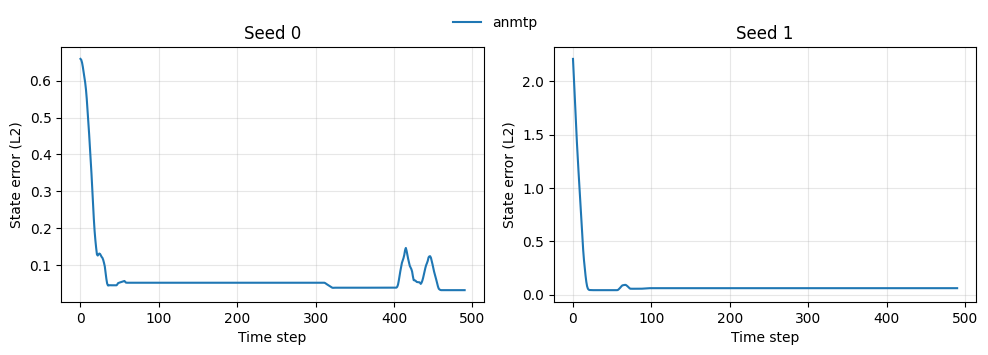

In [4]:
def plot_state_error_grid(data, titles=None, smooth_window=None):
    """
    Plot state error over time for each seed, comparing all controllers.

    Parameters
    ----------
    data : dict
        Nested dict like data[seed][controller]["state_error"] = np.array(...)
    titles : dict or None
        Optional mapping seed -> title string for each subplot.
    smooth_window : int or None
        Optional simple moving-average window (in steps) to smooth curves.
    """
    seeds = sorted(data.keys())
    # Collect all controllers that appear (keeps plot consistent)
    controllers = sorted({c for s in seeds for c in data[s].keys()})

    # Decide grid layout (roughly square)
    n = len(seeds)
    ncols = int(ceil(sqrt(n)))
    nrows = int(ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows), squeeze=False, sharex=False, sharey=False)

    # A simple color/linestyle cycle
    linestyles = ['-', '--', '-.', ':']
    # Use Matplotlib’s default color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)

    legend_handles = None

    for idx, seed in enumerate(seeds):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]

        handles = []
        labels = []

        for j, controller in enumerate(controllers):
            if controller not in data[seed]:
                continue  # skip if missing for this seed

            err = data[seed][controller]["state_error"] 
            # Build x-axis (time index)
            t = np.arange(len(err))

            # Optional smoothing
            if smooth_window and smooth_window > 1:
                k = int(smooth_window)
                if k > 1 and k < len(err):
                    kernel = np.ones(k) / k
                    err = np.convolve(err, kernel, mode='valid')
                    # align time after convolution
                    t = np.arange(len(err))

            ls = linestyles[j % len(linestyles)]
            color = None if colors is None else colors[j % len(colors)]

            line, = ax.plot(t, err, linestyle=ls, label=controller, color=color)
            handles.append(line)
            labels.append(controller)

        title = titles.get(seed) if isinstance(titles, dict) else None
        ax.set_title(title if title else f"Seed {seed}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("State error (L2)" if handles else "State error")
        ax.grid(True, alpha=0.3)

        # Keep first non-empty handles to build a single figure legend later
        if legend_handles is None and handles:
            legend_handles = (handles, labels)

    # Hide any empty subplots (if seeds don't fill the grid)
    for k in range(len(seeds), nrows*ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis('off')

    if legend_handles:
        fig.legend(*legend_handles, loc='upper center', ncol=min(4, len(controllers)), frameon=False, bbox_to_anchor=(0.5, 1.02))

    fig.tight_layout()
    plt.show() 
    
plot_state_error_grid(data, smooth_window=10)

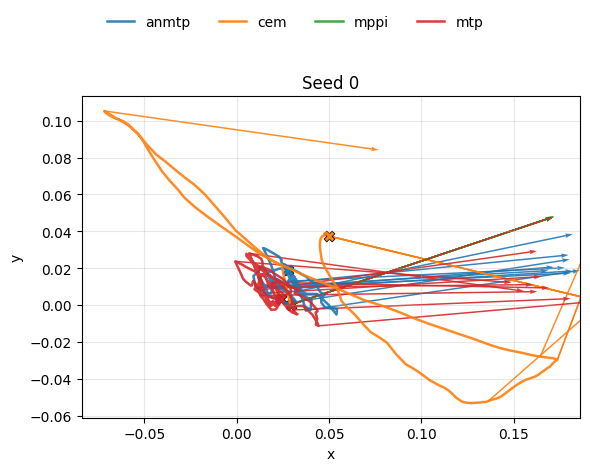

In [4]:
def _wrap_angle(a):
    """Wrap angles to [-pi, pi] for consistent arrows."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def _arrow_components(yaw, scale=0.2):
    """Given yaw (rad), return unit vector scaled for quiver."""
    return np.cos(yaw) * scale, np.sin(yaw) * scale

def plot_T_orientation_grid(data, titles=None, arrow_every=20, arrow_scale=0.2):
    """
    Plot T orientation (x, y, yaw) as trajectories with heading arrows.
    One subplot per seed, multiple controllers overlaid.

    Parameters
    ----------
    data : dict
        Nested dict like data[seed][controller]["T_pos"] = array(T,3) [x,y,yaw]
    titles : dict or None
        Optional mapping seed -> title string.
    arrow_every : int
        Plot an orientation arrow every N steps to avoid clutter.
    arrow_scale : float
        Length of heading arrows (in data units).
    """
    seeds = sorted(data.keys())
    controllers = sorted({c for s in seeds for c in data[s].keys()})

    n = len(seeds)
    ncols = int(ceil(sqrt(n))) if n > 1 else 1
    nrows = int(ceil(n / ncols)) if n > 1 else 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)

    legend_handles = None

    for idx, seed in enumerate(seeds):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]

        handles = []
        labels = []

        for j, controller in enumerate(controllers):
            if controller not in data[seed] or "T_pos" not in data[seed][controller]:
                continue

            T = np.asarray(data[seed][controller]["T_pos"])
            if T.ndim != 2 or T.shape[1] < 3:
                continue  # skip malformed

            x, y, yaw = T[:, 0], T[:, 1], T[:, 2]
            # Heuristic: if yaw looks like degrees (values > 2π), convert to radians.
            if np.nanmax(np.abs(yaw)) > 2*np.pi + 1e-6:
                yaw = np.deg2rad(yaw)
            yaw = _wrap_angle(yaw)

            color = None if colors is None else colors[j % len(colors)]
            ln, = ax.plot(x, y, label=controller, linewidth=1.8, alpha=0.9, color=color)
            handles.append(ln)
            labels.append(controller)

            # Heading arrows
            idxs = np.arange(0, len(x), max(1, int(arrow_every)))
            u, v = _arrow_components(yaw[idxs], scale=arrow_scale)
            ax.quiver(x[idxs], y[idxs], u, v, angles='xy', scale_units='xy', scale=1, width=0.003, alpha=0.9, color=color)

            # Start / goal markers (optional if present)
            ax.scatter(x[0], y[0], s=40, marker='o', edgecolor='none', alpha=0.9, color=color)
            ax.scatter(x[-1], y[-1], s=60, marker='X', edgecolor='black', linewidth=0.6, alpha=0.95, color=color)

        title = titles.get(seed) if isinstance(titles, dict) else None
        ax.set_title(title if title else f"Seed {seed}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")  # preserve geometry
        ax.grid(True, alpha=0.3)

        if legend_handles is None and handles:
            legend_handles = (handles, labels)

    # Hide any empty subplots
    for k in range(len(seeds), nrows*ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis('off')

    if legend_handles:
        fig.legend(*legend_handles, loc='upper center', ncol=min(4, len(controllers)),
                   frameon=False, bbox_to_anchor=(0.5, 1.01))

    fig.tight_layout()
    plt.show()
    
    
plot_T_orientation_grid(data, arrow_every=50, arrow_scale=0.15)

(np.float64(0.0006720394478179513),
 np.float64(0.03065077158389613),
 np.float64(-0.00012329978490015496),
 np.float64(0.009547416392888409))

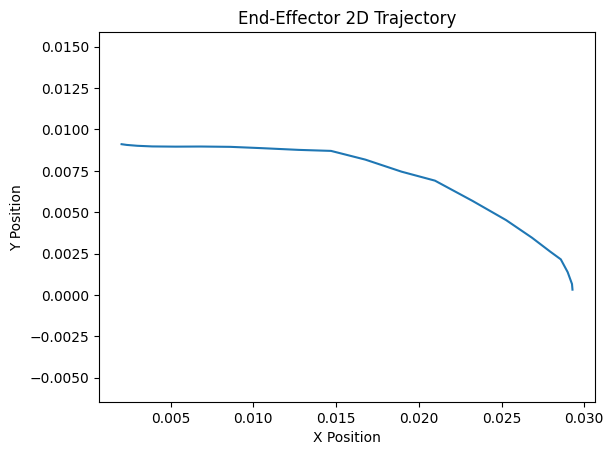

In [19]:
# plot 2d trajceory of end-effector
plt.figure()
plt.plot(data["T_pos"][:, 0], data["T_pos"][:, 1])
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("End-Effector 2D Trajectory")
plt.axis('equal')